# HealthGuard AI — Data Exploration

**Disclaimer:** This notebook explores a *synthetic* (artificially generated) patient dataset created for a student hackathon project. The data is not real, and the `RiskLevel` label was produced by a simple made-up rule (see `data/generate_data.py`). This is a demonstration of an ML pipeline only, not a medical tool.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 1. Load the dataset

In [2]:
df = pd.read_csv("../data/patients.csv")
df.head()

,Age,BMI,BloodPressure,Glucose,Cholesterol,Smoking,Activity,MedicalHistory,RiskLevel
0,69,22.4,115,76,234,0,0,0,Medium
1,32,24.9,117,104,215,1,1,0,Low
2,89,27.6,116,81,177,0,0,0,Medium
3,78,33.4,117,70,262,1,1,1,High
4,38,30.3,115,124,158,0,1,1,Medium


## 2. First 5 rows

In [3]:
df.head()

,Age,BMI,BloodPressure,Glucose,Cholesterol,Smoking,Activity,MedicalHistory,RiskLevel
0,69,22.4,115,76,234,0,0,0,Medium
1,32,24.9,117,104,215,1,1,0,Low
2,89,27.6,116,81,177,0,0,0,Medium
3,78,33.4,117,70,262,1,1,1,High
4,38,30.3,115,124,158,0,1,1,Medium


## 3. Number of rows and columns

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 500
Columns: 9


## 4. Data types

In [5]:
df.dtypes

Age                 int64
BMI               float64
BloodPressure       int64
Glucose             int64
Cholesterol         int64
Smoking             int64
Activity            int64
MedicalHistory      int64
RiskLevel             str
dtype: object

## 5. Missing values

In [6]:
df.isnull().sum()

Age               0
BMI               0
BloodPressure     0
Glucose           0
Cholesterol       0
Smoking           0
Activity          0
MedicalHistory    0
RiskLevel         0
dtype: int64

## 6. Duplicate rows

In [7]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


## 7. Descriptive statistics

In [8]:
df.describe()

,Age,BMI,BloodPressure,Glucose,Cholesterol,Smoking,Activity,MedicalHistory
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.00000,500.000000,500.000000
mean,52.930000,26.015600,126.546000,111.882000,200.81800,0.22400,0.510000,0.250000
std,21.009519,4.956848,14.746077,23.786712,33.84257,0.41734,0.500401,0.433446
min,18.000000,15.000000,90.000000,70.000000,120.00000,0.00000,0.000000,0.000000
25%,34.000000,22.500000,116.000000,95.000000,178.00000,0.00000,0.000000,0.000000
50%,52.000000,25.900000,127.000000,111.000000,200.00000,0.00000,1.000000,0.000000
75%,71.000000,29.200000,136.000000,128.000000,223.00000,0.00000,1.000000,0.250000
max,89.000000,41.400000,164.000000,190.000000,300.00000,1.00000,1.000000,1.000000


## 8. Unique RiskLevel values

In [9]:
df["RiskLevel"].unique()

<StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str

## 9. RiskLevel distribution

In [10]:
risk_counts = df["RiskLevel"].value_counts()
print(risk_counts)

RiskLevel
Medium    254
High      146
Low       100
Name: count, dtype: int64


## 10. Basic graphs

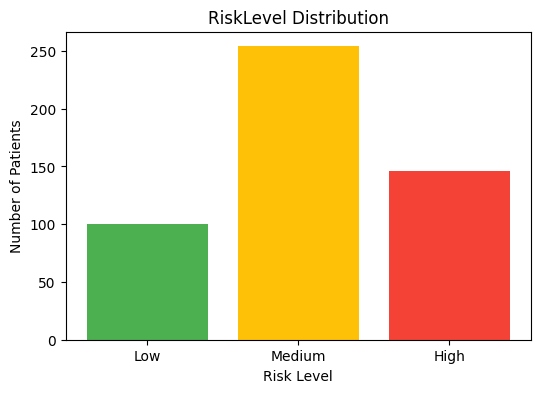

In [11]:
# Bar chart of RiskLevel distribution
risk_counts = df["RiskLevel"].value_counts().reindex(["Low", "Medium", "High"])

plt.figure(figsize=(6, 4))
plt.bar(risk_counts.index, risk_counts.values, color=["#4CAF50", "#FFC107", "#F44336"])
plt.title("RiskLevel Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.show()

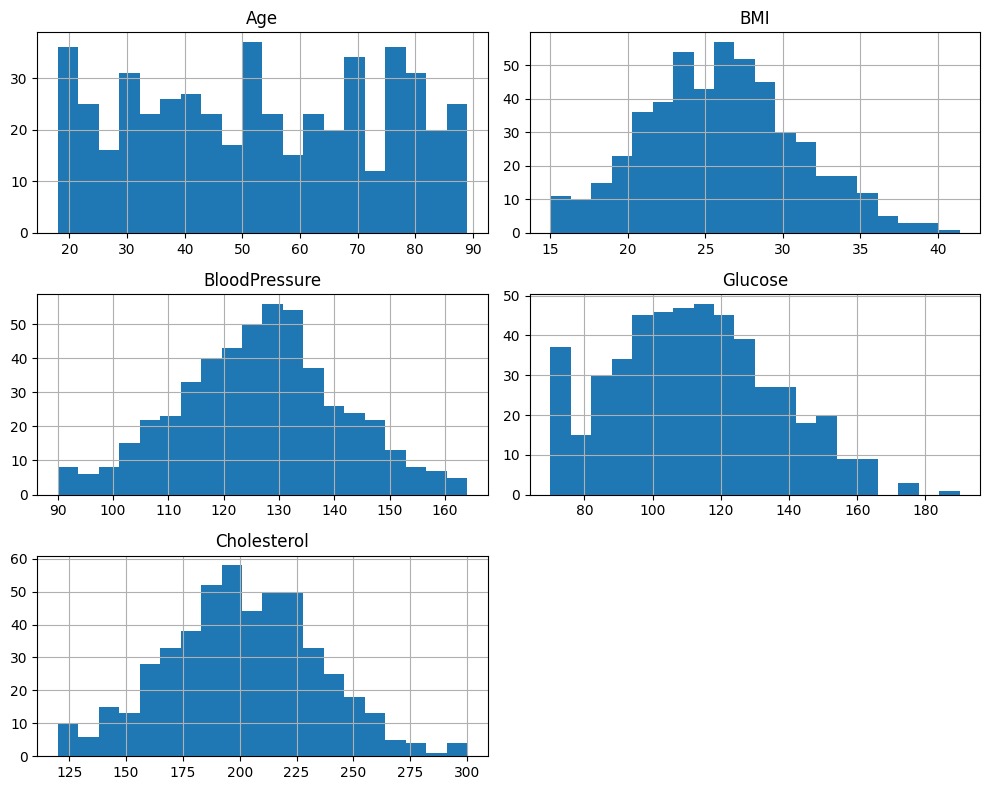

In [12]:
# Histograms of the numerical features
numerical_features = ["Age", "BMI", "BloodPressure", "Glucose", "Cholesterol"]

df[numerical_features].hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

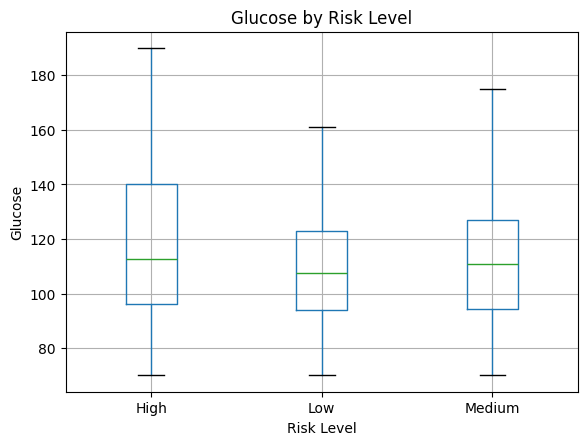

In [13]:
# Boxplot: Glucose by RiskLevel, to see how it varies across classes
plt.figure(figsize=(6, 4))
df.boxplot(column="Glucose", by="RiskLevel")
plt.title("Glucose by Risk Level")
plt.suptitle("")
plt.xlabel("Risk Level")
plt.ylabel("Glucose")
plt.show()